In [1]:
import pandas as pd

# Daten einlesen
df_2324 = pd.read_csv("../data/raw/bundesliga_2023_24.csv")
df_2425 = pd.read_csv("../data/raw/bundesliga_2024_25.csv")

In [2]:
# Erste Übersicht
df_2324.head()

df_2425.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,D1,23/08/2024,19:30,M'gladbach,Leverkusen,2,3,A,0.0,2.0,...,1.86,2.04,1.87,2.06,1.96,2.08,1.91,1.96,1.91,2.07
1,D1,24/08/2024,14:30,Augsburg,Werder Bremen,2,2,D,2.0,1.0,...,1.88,2.05,1.88,2.04,1.88,2.06,1.86,2.03,1.90,2.10
2,D1,24/08/2024,14:30,Freiburg,Stuttgart,3,1,H,1.0,1.0,...,1.95,1.98,1.95,1.97,1.98,2.09,1.87,2.00,1.95,2.04
3,D1,24/08/2024,14:30,Hoffenheim,Holstein Kiel,3,2,H,2.0,0.0,...,2.03,1.90,1.99,1.93,2.16,1.95,2.02,1.86,2.00,1.95
4,D1,24/08/2024,14:30,Mainz,Union Berlin,1,1,D,0.0,0.0,...,2.10,1.83,2.11,1.83,2.13,1.85,2.07,1.81,2.18,1.84


In [3]:
# Größe der Datensätze
df_2324.shape, df_2425.shape

# Spalten anzeigen
df_2324.columns.tolist()

['Div',
 'Date',
 'Time',
 'HomeTeam',
 'AwayTeam',
 'FTHG',
 'FTAG',
 'FTR',
 'HTHG',
 'HTAG',
 'HTR',
 'HS',
 'AS',
 'HST',
 'AST',
 'HF',
 'AF',
 'HC',
 'AC',
 'HY',
 'AY',
 'HR',
 'AR',
 'B365H',
 'B365D',
 'B365A',
 'BWH',
 'BWD',
 'BWA',
 'IWH',
 'IWD',
 'IWA',
 'PSH',
 'PSD',
 'PSA',
 'WHH',
 'WHD',
 'WHA',
 'VCH',
 'VCD',
 'VCA',
 'MaxH',
 'MaxD',
 'MaxA',
 'AvgH',
 'AvgD',
 'AvgA',
 'B365>2.5',
 'B365<2.5',
 'P>2.5',
 'P<2.5',
 'Max>2.5',
 'Max<2.5',
 'Avg>2.5',
 'Avg<2.5',
 'AHh',
 'B365AHH',
 'B365AHA',
 'PAHH',
 'PAHA',
 'MaxAHH',
 'MaxAHA',
 'AvgAHH',
 'AvgAHA',
 'B365CH',
 'B365CD',
 'B365CA',
 'BWCH',
 'BWCD',
 'BWCA',
 'IWCH',
 'IWCD',
 'IWCA',
 'PSCH',
 'PSCD',
 'PSCA',
 'WHCH',
 'WHCD',
 'WHCA',
 'VCCH',
 'VCCD',
 'VCCA',
 'MaxCH',
 'MaxCD',
 'MaxCA',
 'AvgCH',
 'AvgCD',
 'AvgCA',
 'B365C>2.5',
 'B365C<2.5',
 'PC>2.5',
 'PC<2.5',
 'MaxC>2.5',
 'MaxC<2.5',
 'AvgC>2.5',
 'AvgC<2.5',
 'AHCh',
 'B365CAHH',
 'B365CAHA',
 'PCAHH',
 'PCAHA',
 'MaxCAHH',
 'MaxCAHA',
 'AvgCAHH

In [4]:
# Relevante Spalten
relevant_cols = ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR"]

df_2324[relevant_cols].head()

df_2425[relevant_cols].head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR
0,23/08/2024,M'gladbach,Leverkusen,2,3,A
1,24/08/2024,Augsburg,Werder Bremen,2,2,D
2,24/08/2024,Freiburg,Stuttgart,3,1,H
3,24/08/2024,Hoffenheim,Holstein Kiel,3,2,H
4,24/08/2024,Mainz,Union Berlin,1,1,D


In [5]:
# Datum umwandeln
df_2324["Date"] = pd.to_datetime(df_2324["Date"], dayfirst=True)
df_2425["Date"] = pd.to_datetime(df_2425["Date"], dayfirst=True)

# Saison hinzufügen
df_2324["Season"] = "2023/24"
df_2425["Season"] = "2024/25"

C:\Users\BERKE\AppData\Local\Temp\ipykernel_23516\1760375308.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_2425["Season"] = "2024/25"


In [6]:
# Nur relevante Spalten behalten
cols = ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "Season"]

df_2324 = df_2324[cols]
df_2425 = df_2425[cols]

In [7]:
# Datensätze zusammenführen
df = pd.concat([df_2324, df_2425], ignore_index=True)

# Sortieren
df = df.sort_values("Date").reset_index(drop=True)

In [8]:
# Kontrolle
df.head()

df.tail()

df.shape

df["Season"].value_counts()

Season
2023/24    306
2024/25    306
Name: count, dtype: int64

In [9]:
# Ergebnisse insgesamt zählen
df["FTR"].value_counts()

# Ergebnisse pro Saison vergleichen
df.groupby("Season")["FTR"].value_counts()

Season   FTR
2023/24  H      134
         A       91
         D       81
2024/25  H      118
         A      111
         D       77
Name: count, dtype: int64

In [10]:
# Durchschnittliche Tore
df.groupby("Season")[["FTHG", "FTAG"]].mean()

# Gesamttore
df["TotalGoals"] = df["FTHG"] + df["FTAG"]

df.groupby("Season")["TotalGoals"].mean()

Season
2023/24    3.218954
2024/25    3.133987
Name: TotalGoals, dtype: float64

In [11]:
# Prozentuale Verteilung
df.groupby("Season")["FTR"].value_counts(normalize=True) * 100

Season   FTR
2023/24  H      43.790850
         A      29.738562
         D      26.470588
2024/25  H      38.562092
         A      36.274510
         D      25.163399
Name: proportion, dtype: float64

In [12]:
# Statistische Übersicht
df.describe()

,Date,FTHG,FTAG,TotalGoals
count,612,612.000000,612.000000,612.000000
mean,2024-07-09 15:52:56.470588,1.718954,1.457516,3.176471
min,2023-08-18 00:00:00,0.000000,0.000000,0.000000
25%,2024-01-20 00:00:00,1.000000,0.750000,2.000000
50%,2024-07-05 12:00:00,2.000000,1.000000,3.000000
75%,2025-01-15 12:00:00,3.000000,2.000000,4.000000
max,2025-05-17 00:00:00,8.000000,6.000000,9.000000
std,NaN,1.419792,1.246859,1.773113


## Erste deskriptive Analyse

In diesem Schritt wurden die beiden Datensätze (Saison 2023/24 und 2024/25) zusammengeführt und erste Kennzahlen berechnet.

Dabei wurde untersucht:
- Verteilung der Spielergebnisse (Heimsieg, Unentschieden, Auswärtssieg)
- durchschnittliche Anzahl an Toren pro Spiel
- Unterschiede zwischen den beiden Saisons

Erste Ergebnisse zeigen, dass Heimsiege etwas häufiger auftreten als Auswärtssiege. Außerdem lassen sich leichte Unterschiede zwischen den Saisons erkennen.

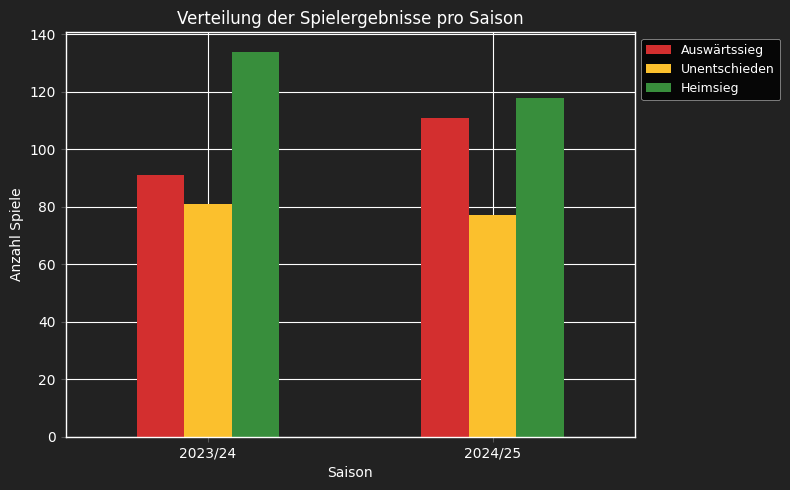

In [13]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 9

# Ergebnisse pro Saison zählen
result_counts = df.groupby("Season")["FTR"].value_counts().unstack()

result_counts


result_counts.plot(
    kind="bar",
    color=["#d32f2f", "#fbc02d", "#388e3c"]  # Rot, Gelb, Grün
)

plt.title("Verteilung der Spielergebnisse pro Saison", color="white")
plt.xlabel("Saison", color="white")
plt.ylabel("Anzahl Spiele", color="white")

plt.xticks(color="white")
plt.yticks(color="white")

plt.legend(
    ["Auswärtssieg", "Unentschieden", "Heimsieg"],
    loc="upper left",
    bbox_to_anchor=(1, 1),
    facecolor="black",
    labelcolor="white"
)

plt.gca().set_facecolor("#222222")   # dunkler Hintergrund
plt.gcf().patch.set_facecolor("#222222")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


### Verteilung der Spielergebnisse

Die Grafik zeigt die Anzahl von Heim-, Unentschieden- und Auswärtssiegen in den beiden betrachteten Saisons.

Auffällig ist, dass Heimsiege in beiden Saisons am häufigsten auftreten.
Unentschieden kommen deutlich seltener vor.

Im Vergleich der beiden Saisons zeigt sich, dass in der Saison 2024/25 mehr Auswärtssiege erzielt wurden als in der Saison 2023/24.

Insgesamt lassen sich Unterschiede in der Verteilung der Spielergebnisse zwischen den beiden Saisons erkennen.

In [14]:
# Durchschnittliche Heim und Auswärtstore pro saison
goals_mean = df.groupby("Season")[["FTHG", "FTAG"]].mean()

goals_mean

,FTHG,FTAG
Season,,
2023/24,1.807190,1.411765
2024/25,1.630719,1.503268


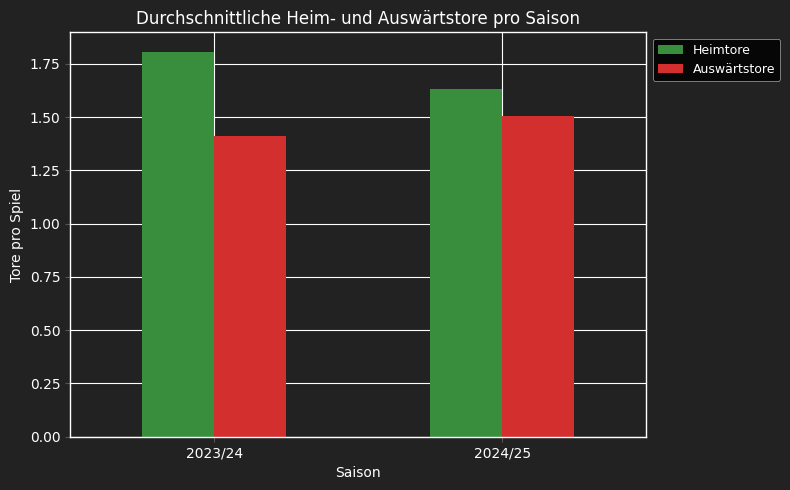

In [15]:
goals_mean.plot(
    kind="bar",
    color=["#388e3c", "#d32f2f"]
)

plt.title("Durchschnittliche Heim- und Auswärtstore pro Saison", color="white")
plt.xlabel("Saison", color="white")
plt.ylabel("Tore pro Spiel", color="white")

plt.xticks(rotation=0, color="white")
plt.yticks(color="white")

plt.legend(
    ["Heimtore", "Auswärtstore"],
    loc="upper left",
    bbox_to_anchor=(1, 1),
    facecolor="black",
    labelcolor="white"
)

plt.gca().set_facecolor("#222222")
plt.gcf().patch.set_facecolor("#222222")

plt.tight_layout()
plt.show()

### Durchschnittliche Heim und Auswärtstore

Die Grafik zeigt die durchschnittliche Anzahl an Heim und Auswärtstoren pro Spiel in den beiden betrachteten Saisons.

Dabei ist zu erkennen, dass in beiden Saisons im Durchschnitt mehr Heimtore als Auswärtstore erzielt wurden. Das spricht für einen leichten Heimvorteil.

Außerdem lassen sich kleine Unterschiede zwischen den beiden Spielzeiten erkennen, was für die spätere Analyse mit dem Elo-Modell relevant sein kann.

## Vorbereitung des Elo Ratings

In [16]:
# Alle Teams extrahieren
teams = pd.concat([df["HomeTeam"], df["AwayTeam"]]).unique()

teams

<StringArray>
['Werder Bremen',      'Augsburg',    'Hoffenheim',    'Leverkusen',
     'Stuttgart',     'Wolfsburg',      'Dortmund',  'Union Berlin',
 'Ein Frankfurt',    'RB Leipzig',    'M'gladbach',    'Heidenheim',
      'Freiburg',        'Bochum',     'Darmstadt',       'FC Koln',
         'Mainz', 'Bayern Munich',      'St Pauli', 'Holstein Kiel']
Length: 20, dtype: str

In [17]:
len(teams)

20

In [18]:
# Start-Elo für jedes Team
elo_ratings = {}

for team in teams:
    elo_ratings[team] = 1500

elo_ratings

{'Werder Bremen': 1500,
 'Augsburg': 1500,
 'Hoffenheim': 1500,
 'Leverkusen': 1500,
 'Stuttgart': 1500,
 'Wolfsburg': 1500,
 'Dortmund': 1500,
 'Union Berlin': 1500,
 'Ein Frankfurt': 1500,
 'RB Leipzig': 1500,
 "M'gladbach": 1500,
 'Heidenheim': 1500,
 'Freiburg': 1500,
 'Bochum': 1500,
 'Darmstadt': 1500,
 'FC Koln': 1500,
 'Mainz': 1500,
 'Bayern Munich': 1500,
 'St Pauli': 1500,
 'Holstein Kiel': 1500}

In [19]:
# Test
elo_ratings["Bayern Munich"]

1500

Für die Berechnung des Elo Ratings wurden zunächst alle Daten extrahiert. Jedem Team wird ein Startwert von 1500 zugewiesen. Dieser Wert dient als Ausgangspunkt für die spätere Berechnung der teamstärken.
Im weiteren Verlauf wird das Rating nach jedem Spiel basierend auf dem Ergebnis angepasst.

## Erwartungswert im Elo Modell


In [20]:
# Funktion für den erwarteten Score
def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

In [21]:
# Test (muss 0.5 sein)
expected_score(1500, 1500)

0.5

In [22]:
# Test (muss größer 0.5 sein)
expected_score(1600, 1500)

0.6400649998028851

In [23]:
# Test (muss kleiner 0.5 sein)
expected_score(1400, 1500)

0.35993500019711494

Im Elo System wird zunächst berechnet, wie hoch die erwartete Punktzahl eines teams vor dem Spiel ist.
Je größer der Unterschied zwischen zwei Ratings ist, desto höher ist die erwartete Gewinnwahrscheinlichkeit des stärkeren Teams.
Im nächsten Schritt wird diese Erwartung mit dem tatsächlichen Ergebnis verglichen.

## Aktualisierung des Elo Ratings

In [24]:
# K-Faktor festlegen
K = 20

In [25]:
def update_elo(rating, expected, actual, k=20):
    return rating + k * (actual - expected)

In [26]:
# Beispiel: Team gewinnt, obwohl Erwartung nur 0.4 war
update_elo(1500, 0.4, 1)

1512.0

In [27]:
# Beispiel: Team verliert, obwohl Erwartung hoch war
update_elo(1500, 0.7, 0)

1486.0

Nach jedem Spiel wird das Rating eines Teams basierend auf dem tatsächlichen Ergebnis und dem erwarteten Ergebnis angepasst.
Ein Sieg führt zu einem Anstieg des Ratings, eine Niederlage zu einem Rückgang. Die Höhe der Anpassung hängt vom Unterschied zwischen Erwartung und Ergebnis ab.

## Anwendung des Elo Modells auf alle Spiele

In [28]:
# Ratings neu initialisieren
elo_ratings = {}

for team in teams:
    elo_ratings[team] = 1500

In [29]:
# Listen für Ratings vor dem Spiel
home_elo_before = []
away_elo_before = []

In [30]:
for _, row in df.iterrows():
    home_team = row["HomeTeam"]
    away_team = row["AwayTeam"]

    home_rating = elo_ratings[home_team]
    away_rating = elo_ratings[away_team]

    home_elo_before.append(home_rating)
    away_elo_before.append(away_rating)

    expected_home = expected_score(home_rating, away_rating)
    expected_away = expected_score(away_rating, home_rating)

    if row["FTR"] == "H":
        actual_home = 1
        actual_away = 0
    elif row["FTR"] == "D":
        actual_home = 0.5
        actual_away = 0.5
    else:
        actual_home = 0
        actual_away = 1

    new_home_rating = update_elo(home_rating, expected_home, actual_home, K)
    new_away_rating = update_elo(away_rating, expected_away, actual_away, K)

    elo_ratings[home_team] = new_home_rating
    elo_ratings[away_team] = new_away_rating

In [31]:
# Ratings vor dem Spiel in den Datensatz schreiben
df["HomeEloBefore"] = home_elo_before
df["AwayEloBefore"] = away_elo_before

In [32]:
df[["Date", "HomeTeam", "AwayTeam", "HomeEloBefore", "AwayEloBefore", "FTR"]].head(10)

,Date,HomeTeam,AwayTeam,HomeEloBefore,AwayEloBefore,FTR
0,2023-08-18,Werder Bremen,Bayern Munich,1500.0,1500.0,A
1,2023-08-19,Augsburg,M'gladbach,1500.0,1500.0,D
2,2023-08-19,Hoffenheim,Freiburg,1500.0,1500.0,A
3,2023-08-19,Leverkusen,RB Leipzig,1500.0,1500.0,H
4,2023-08-19,Stuttgart,Bochum,1500.0,1500.0,H
5,2023-08-19,Wolfsburg,Heidenheim,1500.0,1500.0,H
6,2023-08-19,Dortmund,FC Koln,1500.0,1500.0,H
7,2023-08-20,Union Berlin,Mainz,1500.0,1500.0,H
8,2023-08-20,Ein Frankfurt,Darmstadt,1500.0,1500.0,H
9,2023-08-25,RB Leipzig,Stuttgart,1490.0,1510.0,H


In [33]:
# Aktuelle Ratings nach allen Spielen
elo_ratings

{'Werder Bremen': 1526.8806921884238,
 'Augsburg': 1477.0065727463364,
 'Hoffenheim': 1448.1451129319012,
 'Leverkusen': 1678.1512185405527,
 'Stuttgart': 1555.961843448436,
 'Wolfsburg': 1467.237757234868,
 'Dortmund': 1585.4452925508735,
 'Union Berlin': 1460.3816565934997,
 'Ein Frankfurt': 1566.8807339267412,
 'RB Leipzig': 1548.9972417875176,
 "M'gladbach": 1463.4195598183212,
 'Heidenheim': 1426.546868493311,
 'Freiburg': 1529.759706871611,
 'Bochum': 1395.979118012767,
 'Darmstadt': 1362.4964491692215,
 'FC Koln': 1429.553036575522,
 'Mainz': 1526.2432486604196,
 'Bayern Munich': 1684.0090245907988,
 'St Pauli': 1446.540560735935,
 'Holstein Kiel': 1420.3643051229435}



In diesem Schritt wurde das Elo Modell auf alle Spiele angewendet. Dafür wurden die Ratings der Teams zunächst initialisiert und anschließend für jedes Spiel basierend auf Erwartung und tatsächlichem Ergebnis aktualisiert.

Dabei wurde für jedes Spiel das Elo Rating vor dem Spiel gespeichert, sodass eine spätere analyse möglich ist.

Die berechneten Elo Werte zeigen, dass sich die Teams im Verlauf der Saisons unterschiedlich entwickeln. Stärkere Teams erreichen höhere Ratings, während schwächere Teams entsprechend niedrigere Werte haben.

### Elo Tabelle

In [34]:
elo_table = pd.DataFrame(
    elo_ratings.items(),
    columns=["Team", "Elo"]
)

elo_table = elo_table.sort_values("Elo", ascending=False).reset_index(drop=True)

elo_table

,Team,Elo
0,Bayern Munich,1684.009025
1,Leverkusen,1678.151219
2,Dortmund,1585.445293
3,Ein Frankfurt,1566.880734
4,Stuttgart,1555.961843
5,RB Leipzig,1548.997242
6,Freiburg,1529.759707
7,Werder Bremen,1526.880692
8,Mainz,1526.243249
9,Augsburg,1477.006573


In [35]:
elo_table.head(10)

,Team,Elo
0,Bayern Munich,1684.009025
1,Leverkusen,1678.151219
2,Dortmund,1585.445293
3,Ein Frankfurt,1566.880734
4,Stuttgart,1555.961843
5,RB Leipzig,1548.997242
6,Freiburg,1529.759707
7,Werder Bremen,1526.880692
8,Mainz,1526.243249
9,Augsburg,1477.006573



Die Tabelle zeigt die finalen Elo Werte aller Teams nach Anwendung des Modells auf beide Saisons. Dabei ist zu beachten, dass die beiden Saisons gemeinsam ausgewertet wurden. Das bedeutet, dass sich die Elo Werte über den gesamten Zeitraum hinweg entwickeln und nicht getrennt pro Saison betrachtet werden.

Auffällig ist, dass Teams wie Bayern München und Leverkusen hohe Elo Werte erreichen, was grundsätzlich zu den sportlichen Leistungen passt. Gleichzeitig kann diese gemeinsame Betrachtung zu Verzerrungen führen, da sich die Teamzusammensetzung zwischen den Saisons verändert (z. B. Auf und Absteiger).

Diese erste Elo Tabelle dient daher als Ausgangspunkt für weitere Analysen, insbesondere für einen späteren Vergleich der einzelnen Saisons.

## Vorbereitung des Saisonvergleichs

Da sich die Teamzusammensetzung zwischen den beiden Saisons verändert, werden die Daten im nächsten Schritt getrennt betrachtet.

Dadurch kann später untersucht werden, wie sich die Elo Werte und Ergebnisse in den beiden Spielzeiten jeweils entwickeln.

In [36]:
# Datensätze nach Saison trennen
df_2324_only = df[df["Season"] == "2023/24"].copy()
df_2425_only = df[df["Season"] == "2024/25"].copy()

In [37]:
# Größen der beiden Saison-Datensätze prüfen
df_2324_only.shape, df_2425_only.shape

((306, 10), (306, 10))

In [38]:
# Erste Zeilen anschauen
df_2324_only.head()

df_2425_only.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,Season,TotalGoals,HomeEloBefore,AwayEloBefore
306,2024-08-23,M'gladbach,Leverkusen,2,3,A,2024/25,5,1450.350332,1681.465636
307,2024-08-24,Augsburg,Werder Bremen,2,2,D,2024/25,4,1463.281489,1494.095786
308,2024-08-24,Freiburg,Stuttgart,3,1,H,2024/25,4,1467.457019,1609.612651
309,2024-08-24,Hoffenheim,Holstein Kiel,3,2,H,2024/25,5,1496.453113,1500.000000
310,2024-08-24,Mainz,Union Berlin,1,1,D,2024/25,2,1484.035267,1438.767799


In [39]:
# Teams pro Saison prüfen
teams_2324 = pd.concat([df_2324_only["HomeTeam"], df_2324_only["AwayTeam"]]).unique()
teams_2425 = pd.concat([df_2425_only["HomeTeam"], df_2425_only["AwayTeam"]]).unique()

len(teams_2324), len(teams_2425)

(18, 18)

In [40]:
sorted(teams_2324)

['Augsburg',
 'Bayern Munich',
 'Bochum',
 'Darmstadt',
 'Dortmund',
 'Ein Frankfurt',
 'FC Koln',
 'Freiburg',
 'Heidenheim',
 'Hoffenheim',
 'Leverkusen',
 "M'gladbach",
 'Mainz',
 'RB Leipzig',
 'Stuttgart',
 'Union Berlin',
 'Werder Bremen',
 'Wolfsburg']

In [41]:
sorted(teams_2425)

['Augsburg',
 'Bayern Munich',
 'Bochum',
 'Dortmund',
 'Ein Frankfurt',
 'Freiburg',
 'Heidenheim',
 'Hoffenheim',
 'Holstein Kiel',
 'Leverkusen',
 "M'gladbach",
 'Mainz',
 'RB Leipzig',
 'St Pauli',
 'Stuttgart',
 'Union Berlin',
 'Werder Bremen',
 'Wolfsburg']

In diesem Schritt wurden die beiden Saisons getrennt betrachtet, um die Daten später gezielter vergleichen zu können.

Dafür wurde der gemeinsame Datensatz in zwei einzelne Datensätze für die Saisons 2023/24 und 2024/25 aufgeteilt. Anschließend wurde geprüft, ob beide Datensätze die erwartete Anzahl an Spielen enthalten.

Außerdem wurde die Teamzusammensetzung beider Saisons verglichen. Dabei zeigt sich, dass sich die Teams zwischen den Spielzeiten teilweise unterscheiden, was für die spätere Elo Analyse relevant ist.

## Elo Berechnung pro Saison

In [42]:
# Elo Ratings für Saison 2023/24

elo_2324 = {}

# Teams initialisieren
teams_2324 = pd.concat([df_2324_only["HomeTeam"], df_2324_only["AwayTeam"]]).unique()

for team in teams_2324:
    elo_2324[team] = 1500

In [43]:
# Elo für jedes Spiel berechnen

for _, row in df_2324_only.iterrows():
    home = row["HomeTeam"]
    away = row["AwayTeam"]

    home_elo = elo_2324[home]
    away_elo = elo_2324[away]

    # Erwartete Werte
    expected_home = 1 / (1 + 10 ** ((away_elo - home_elo) / 400))
    expected_away = 1 - expected_home

    # Ergebnis
    if row["FTR"] == "H":
        score_home, score_away = 1, 0
    elif row["FTR"] == "A":
        score_home, score_away = 0, 1
    else:
        score_home, score_away = 0.5, 0.5

    # Update
    K = 20
    elo_2324[home] = home_elo + K * (score_home - expected_home)
    elo_2324[away] = away_elo + K * (score_away - expected_away)

In [44]:
elo_table_2324 = pd.DataFrame(
    elo_2324.items(),
    columns=["Team", "Elo"]
)

elo_table_2324 = elo_table_2324.sort_values("Elo", ascending=False).reset_index(drop=True)

elo_table_2324.head(18)

,Team,Elo
0,Leverkusen,1681.465636
1,Stuttgart,1609.612651
2,Bayern Munich,1578.674335
3,RB Leipzig,1575.305728
4,Dortmund,1569.261993
5,Ein Frankfurt,1511.345050
6,Hoffenheim,1496.453113
7,Heidenheim,1495.447444
8,Werder Bremen,1494.095786
9,Mainz,1484.035267


Für die Saison 2023/24 wurde das Elo Modell separat berechnet.

Alle Teams wurden zu Beginn mit einem Rating von 1500 initialisiert. Im Verlauf der Saison wurden die Werte basierend auf den Spielergebnissen kontinuierlich angepasst.

Die Tabelle zeigt die Teams mit den höchsten Elo Werten am Ende der Saison. Diese spiegeln in der Regel die sportliche Leistung der Teams wider.

In [45]:
# Elo Ratings für Saison 2024/25

elo_2425 = {}

# Teams initialisieren
teams_2425 = pd.concat([df_2425_only["HomeTeam"], df_2425_only["AwayTeam"]]).unique()

for team in teams_2425:
    elo_2425[team] = 1500

In [46]:
# Elo für jedes Spiel berechnen

for _, row in df_2425_only.iterrows():
    home = row["HomeTeam"]
    away = row["AwayTeam"]

    home_elo = elo_2425[home]
    away_elo = elo_2425[away]

    # Erwartete Werte
    expected_home = 1 / (1 + 10 ** ((away_elo - home_elo) / 400))
    expected_away = 1 - expected_home

    # Ergebnis
    if row["FTR"] == "H":
        score_home, score_away = 1, 0
    elif row["FTR"] == "A":
        score_home, score_away = 0, 1
    else:
        score_home, score_away = 0.5, 0.5

    # Update
    K = 20
    elo_2425[home] = home_elo + K * (score_home - expected_home)
    elo_2425[away] = away_elo + K * (score_away - expected_away)

In [47]:
elo_table_2425 = pd.DataFrame(
    elo_2425.items(),
    columns=["Team", "Elo"]
)

elo_table_2425 = elo_table_2425.sort_values("Elo", ascending=False).reset_index(drop=True)

elo_table_2425.head(18)

,Team,Elo
0,Bayern Munich,1645.134514
1,Leverkusen,1597.230552
2,Ein Frankfurt,1555.288000
3,Dortmund,1553.464996
4,Freiburg,1534.623466
5,Mainz,1524.901570
6,Werder Bremen,1521.810779
7,RB Leipzig,1514.180697
8,Stuttgart,1508.057780
9,Augsburg,1483.211393


Für die Saison 2024/25 wurde das Elo Modell ebenfalls separat berechnet.

Auch hier wurden alle Teams zunächst mit einem Startwert von 1500 initialisiert. Im Verlauf der Saison wurden die Elo Werte anhand der tatsächlichen Spielergebnisse angepasst.

Die resultierende Tabelle zeigt die Teams mit den höchsten Elo Werten am Ende der Saison 2024/25 und ermöglicht später einen direkten Vergleich mit der Saison 2023/24.

In [48]:
elo_table_2324.head(18)

,Team,Elo
0,Leverkusen,1681.465636
1,Stuttgart,1609.612651
2,Bayern Munich,1578.674335
3,RB Leipzig,1575.305728
4,Dortmund,1569.261993
5,Ein Frankfurt,1511.345050
6,Hoffenheim,1496.453113
7,Heidenheim,1495.447444
8,Werder Bremen,1494.095786
9,Mainz,1484.035267


In [49]:
elo_table_2425.head(18)

,Team,Elo
0,Bayern Munich,1645.134514
1,Leverkusen,1597.230552
2,Ein Frankfurt,1555.288000
3,Dortmund,1553.464996
4,Freiburg,1534.623466
5,Mainz,1524.901570
6,Werder Bremen,1521.810779
7,RB Leipzig,1514.180697
8,Stuttgart,1508.057780
9,Augsburg,1483.211393


In [50]:
top5_2324 = elo_table_2324.head(5).copy()
top5_2425 = elo_table_2425.head(5).copy()

top5_2324["Season"] = "2023/24"
top5_2425["Season"] = "2024/25"

elo_top_compare = pd.concat([top5_2324, top5_2425], ignore_index=True)

elo_top_compare

,Team,Elo,Season
0,Leverkusen,1681.465636,2023/24
1,Stuttgart,1609.612651,2023/24
2,Bayern Munich,1578.674335,2023/24
3,RB Leipzig,1575.305728,2023/24
4,Dortmund,1569.261993,2023/24
5,Bayern Munich,1645.134514,2024/25
6,Leverkusen,1597.230552,2024/25
7,Ein Frankfurt,1555.288000,2024/25
8,Dortmund,1553.464996,2024/25
9,Freiburg,1534.623466,2024/25


### Vergleich der saisonweisen Elo Tabellen

Wenn man sich die beiden Tabellen anschaut, fällt auf, dass sich die Ergebnisse zwischen den Saisons teilweise unterscheiden. Das zeigt, dass es sinnvoll ist, die Spielzeiten getrennt zu betrachten und nicht nur zusammenzufassen.

In der Saison 2023/24 sieht man zum Beispiel, dass Teams wie Leverkusen und Bayern München sehr hohe Werte erreichen. Das passt auch zur Realität, da Leverkusen in dieser Saison Meister geworden ist und insgesamt eine sehr starke Leistung gezeigt hat.

In der Saison 2024/25 verändert sich das Bild leicht. Einige Teams bleiben oben dabei, andere fallen etwas ab oder kommen neu dazu. Das liegt unter anderem daran, dass sich die Teams durch Transfers, Formschwankungen oder auch Auf und Abstieg verändern.

Durch die getrennte Betrachtung wird deutlich, dass die Elo Werte stärker den tatsächlichen Verlauf einer einzelnen Saison widerspiegeln. Im gemischten Modell gehen solche Unterschiede eher verloren, da sich die Werte über beide Saisons hinweg vermischen.

Insgesamt zeigt der Vergleich, dass es sinnvoll ist, beide Ansätze zu betrachten. Das gemeinsame Modell gibt einen groben Überblick, während die saisonweise Analyse genauer zeigt, wie sich die Leistung der Teams innerhalb einer Spielzeit entwickelt.

## Elo Verlauf eines Teams nach Saison


In [51]:
# Team auswählen
team = "Bayern Munich"

In [52]:
def team_elo_history_by_season(df_season, team, k=20):
    teams = pd.concat([df_season["HomeTeam"], df_season["AwayTeam"]]).unique()

    ratings = {}
    for t in teams:
        ratings[t] = 1500

    dates = []
    elo_values = []

    for _, row in df_season.iterrows():
        home = row["HomeTeam"]
        away = row["AwayTeam"]

        home_elo = ratings[home]
        away_elo = ratings[away]

        if home == team:
            dates.append(row["Date"])
            elo_values.append(home_elo)
        elif away == team:
            dates.append(row["Date"])
            elo_values.append(away_elo)

        expected_home = expected_score(home_elo, away_elo)
        expected_away = expected_score(away_elo, home_elo)

        if row["FTR"] == "H":
            actual_home = 1
            actual_away = 0
        elif row["FTR"] == "A":
            actual_home = 0
            actual_away = 1
        else:
            actual_home = 0.5
            actual_away = 0.5

        ratings[home] = update_elo(home_elo, expected_home, actual_home, k)
        ratings[away] = update_elo(away_elo, expected_away, actual_away, k)

    history = pd.DataFrame({
        "Date": dates,
        "Elo": elo_values
    })

    return history

In [53]:
team_2324 = team_elo_history_by_season(df_2324_only, team)
team_2425 = team_elo_history_by_season(df_2425_only, team)

team_2324.head()


,Date,Elo
0,2023-08-18,1500.000000
1,2023-08-27,1510.000000
2,2023-09-02,1519.712256
3,2023-09-15,1528.867370
4,2023-09-23,1528.859402


In [54]:
team_2425.head()

,Date,Elo
0,2024-08-25,1500.000000
1,2024-09-01,1510.000000
2,2024-09-14,1520.000000
3,2024-09-21,1528.853767
4,2024-09-28,1538.319427


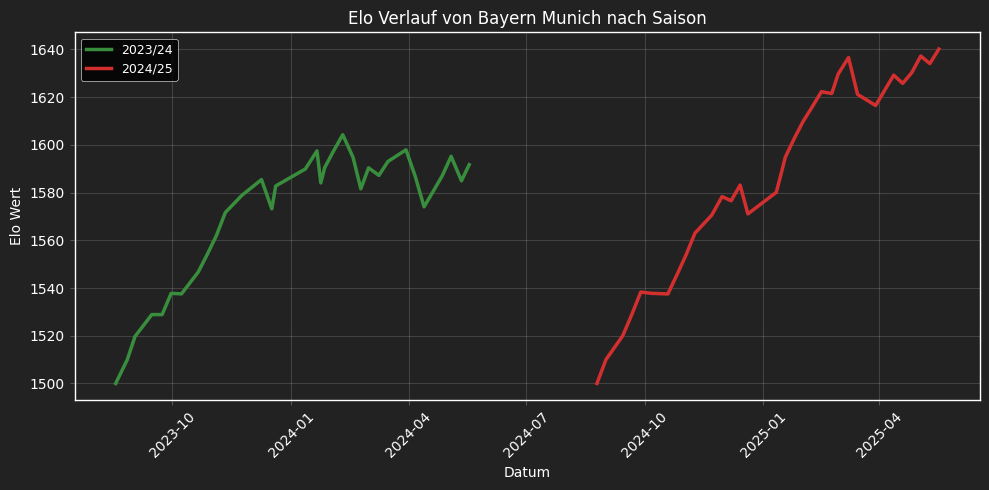

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    team_2324["Date"],
    team_2324["Elo"],
    label="2023/24",
    color="#388e3c",
    linewidth=2.5
)

plt.plot(
    team_2425["Date"],
    team_2425["Elo"],
    label="2024/25",
    color="#d32f2f",
    linewidth=2.5
)

ax = plt.gca()
ax.set_facecolor("#222222")
plt.gcf().patch.set_facecolor("#222222")

plt.title(f"Elo Verlauf von {team} nach Saison", color="white")
plt.xlabel("Datum", color="white")
plt.ylabel("Elo Wert", color="white")

plt.xticks(rotation=45, color="white")
plt.yticks(color="white")

for spine in ax.spines.values():
    spine.set_color("white")

plt.legend(
    facecolor="black",
    edgecolor="white",
    labelcolor="white",
    loc="upper left"
)

plt.grid(color="white", alpha=0.15)

plt.tight_layout()
plt.show()

In dieser Darstellung wird der Verlauf des Elo Wertes für ein einzelnes Team getrennt nach Saison betrachtet.

Dabei startet jede Saison wieder mit einem Anfangswert von 1500. Dadurch lässt sich besser erkennen, wie sich die Leistung des Teams innerhalb einer einzelnen Spielzeit entwickelt.

Im Vergleich der beiden Saisons wird sichtbar, ob das Team konstant performt oder stärkere Schwankungen aufweist. Steigende Werte deuten auf gute Ergebnisse hin, während fallende Werte auf schwächere Phasen schließen lassen.

Die getrennte Betrachtung ist sinnvoll, da sich die Teams zwischen den Saisons verändern und die Ergebnisse sonst miteinander vermischt würden.

## Vergleich des Elo Verlaufs mehrerer Teams

In [56]:
common_teams = sorted(set(teams_2324).intersection(set(teams_2425)))
common_teams

['Augsburg',
 'Bayern Munich',
 'Bochum',
 'Dortmund',
 'Ein Frankfurt',
 'Freiburg',
 'Heidenheim',
 'Hoffenheim',
 'Leverkusen',
 "M'gladbach",
 'Mainz',
 'RB Leipzig',
 'Stuttgart',
 'Union Berlin',
 'Werder Bremen',
 'Wolfsburg']

In [57]:
teams = ["Bayern Munich", "Leverkusen", "Dortmund", "Bochum"]

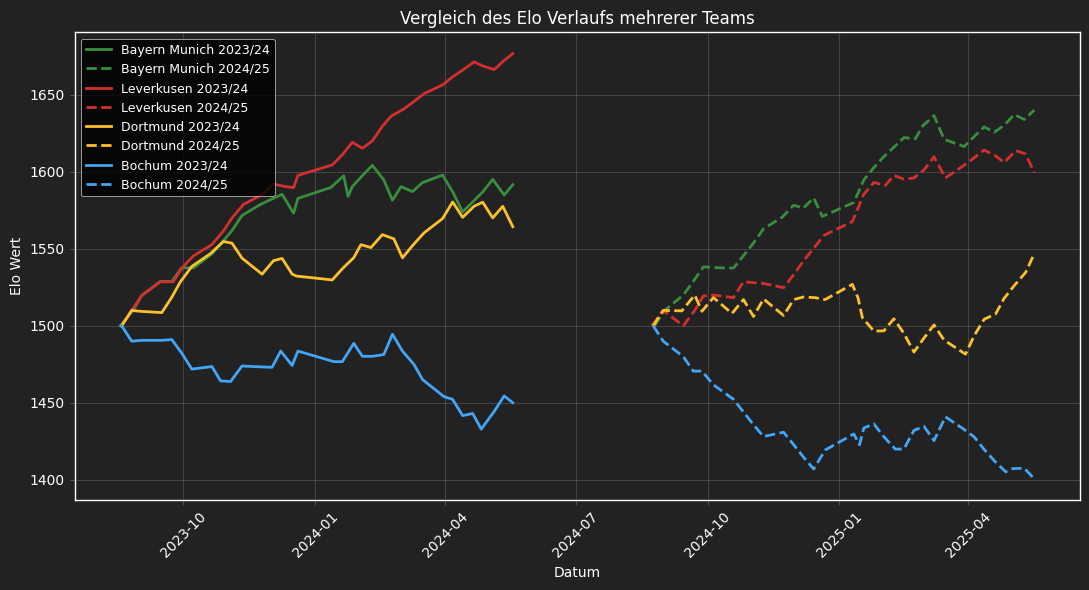

In [58]:
plt.figure(figsize=(11, 6))

colors = {
    "Bayern Munich": "#388e3c",
    "Leverkusen": "#d32f2f",
    "Dortmund": "#fbc02d",
    "Bochum": "#42a5f5"
}

for team in teams:
    team_2324 = team_elo_history_by_season(df_2324_only, team)
    team_2425 = team_elo_history_by_season(df_2425_only, team)

    plt.plot(
        team_2324["Date"],
        team_2324["Elo"],
        linestyle="solid",
        color=colors[team],
        linewidth=2,
        label=f"{team} 2023/24"
    )

    plt.plot(
        team_2425["Date"],
        team_2425["Elo"],
        linestyle="dashed",
        color=colors[team],
        linewidth=2,
        label=f"{team} 2024/25"
    )

ax = plt.gca()
ax.set_facecolor("#222222")
plt.gcf().patch.set_facecolor("#222222")

plt.title("Vergleich des Elo Verlaufs mehrerer Teams", color="white")
plt.xlabel("Datum", color="white")
plt.ylabel("Elo Wert", color="white")

plt.xticks(rotation=45, color="white")
plt.yticks(color="white")

for spine in ax.spines.values():
    spine.set_color("white")

plt.legend(
    facecolor="black",
    edgecolor="white",
    labelcolor="white",
    loc="upper left"
)

plt.grid(color="white", alpha=0.15)

plt.tight_layout()
plt.show()

In diesem Plot werden vier Teams aus unterschiedlichen Leistungsbereichen miteinander verglichen, um ein besseres Gefühl dafür zu bekommen, wie sich das Elo Modell im Verlauf der Saison verhält.

Auffällig ist direkt, dass Leverkusen in der Saison 2023/24 einen sehr starken und relativ konstanten Anstieg zeigt. Das passt auch gut zur Realität, da Leverkusen in dieser Saison Meister geworden ist. Die Entwicklung wirkt im Vergleich zu den anderen Teams deutlich stabiler und weniger schwankend.

Bayern München bewegt sich ebenfalls auf einem hohen Niveau, zeigt aber etwas mehr Schwankungen im Verlauf. Trotzdem bleibt das Team insgesamt konstant im oberen Bereich, was auch zu den Erwartungen an ein Top Team passt.

Dortmund liegt insgesamt etwas unter Bayern und Leverkusen und zeigt stärkere Schwankungen. Das könnte darauf hindeuten, dass die Leistungen nicht ganz so konstant sind und sich einzelne Spiele stärker auf das Rating auswirken.

Bochum bildet einen klaren Gegenpol zu den Top Teams. Die Elo Werte liegen deutlich niedriger und zeigen teilweise auch stärkere Ausschläge nach unten. Dadurch wird gut sichtbar, dass das Modell nicht nur starke Teams erkennt, sondern auch Unterschiede im unteren Bereich der Tabelle abbildet.

Interessant ist auch der Vergleich zwischen den beiden Saisons. Alle Teams starten wieder bei 1500, entwickeln sich aber unterschiedlich weiter. Das zeigt, dass jede Saison für sich betrachtet werden sollte, da sich Form, Kader und Ergebnisse verändern können.

Insgesamt wirkt das Elo Modell hier plausibel, da die Entwicklung der Teams gut zu den tatsächlichen Leistungen in der Bundesliga passt.

## Vorhersage von Spielergebnissen mit dem Elo Modell

In [59]:
def predict_result(home_elo, away_elo):
    if home_elo > away_elo:
        return "H"
    elif home_elo < away_elo:
        return "A"
    else:
        return "D"

In [60]:
df["Predicted"] = df.apply(
    lambda row: predict_result(row["HomeEloBefore"], row["AwayEloBefore"]),
    axis=1
)

In [61]:
accuracy = (df["Predicted"] == df["FTR"]).mean()

accuracy

np.float64(0.477124183006536)

In [62]:
accuracy * 100

np.float64(47.712418300653596)

In [63]:
accuracy_percent = round(accuracy * 100, 2)

accuracy_percent

np.float64(47.71)

In [64]:
season_accuracy = (
    df.groupby("Season")
    .apply(lambda x: (x["Predicted"] == x["FTR"]).mean() * 100)
    .round(2)
)

season_accuracy

Season
2023/24    46.08
2024/25    49.35
dtype: float64

In [65]:
prediction_table = pd.crosstab(df["Predicted"], df["FTR"])

prediction_table

FTR,A,D,H
Predicted,,,
A,136,78,91
D,3,1,6
H,63,79,155


In [66]:
df["Baseline"] = "H"

In [67]:
baseline_accuracy = (df["Baseline"] == df["FTR"]).mean()

baseline_accuracy_percent = round(baseline_accuracy * 100, 2)

baseline_accuracy_percent

np.float64(41.18)

In [68]:
comparison_table = pd.DataFrame({
    "Modell": ["Elo Modell", "Baseline Heimteam"],
    "Accuracy in Prozent": [accuracy_percent, baseline_accuracy_percent]
})

comparison_table

,Modell,Accuracy in Prozent
0,Elo Modell,47.71
1,Baseline Heimteam,41.18


In [69]:
baseline_season_accuracy = (
    df.groupby("Season")
    .apply(lambda x: (x["Baseline"] == x["FTR"]).mean() * 100)
    .round(2)
)

baseline_season_accuracy

Season
2023/24    43.79
2024/25    38.56
dtype: float64

In [70]:
season_comparison = pd.DataFrame({
    "Elo Modell": season_accuracy,
    "Baseline Heimteam": baseline_season_accuracy
})

season_comparison

,Elo Modell,Baseline Heimteam
Season,,
2023/24,46.08,43.79
2024/25,49.35,38.56


In diesem Schritt wurde überprüft, wie gut das Elo Modell tatsächlich Spielergebnisse vorhersagen kann.

Dafür wurde für jedes Spiel das Team mit dem höheren Elo Wert als Sieger vorhergesagt. Diese Vorhersagen wurden dann mit den echten Ergebnissen aus dem Datensatz verglichen.

Die Gesamt-Accuracy liegt bei etwa 47.7 Prozent. Das bedeutet, dass das Modell in weniger als der Hälfte der Fälle richtig liegt. Auf den ersten Blick wirkt das nicht besonders hoch, allerdings ist Fußball generell schwer vorherzusagen, da viele Spiele relativ ausgeglichen sind.

Wenn man sich die beiden Saisons getrennt anschaut, fällt auf, dass das Modell in der Saison 2024/25 mit etwa 49.35 Prozent etwas besser funktioniert als in der Saison 2023/24 mit etwa 46.08 Prozent. Ein möglicher Grund dafür könnte sein, dass die Saison 2024/25 etwas „klarere“ Strukturen hatte, zum Beispiel durch dominante Teams wie Bayern München, die häufig als Favorit in Spiele gehen. Solche Situationen sind für ein Elo Modell einfacher vorherzusagen, da die Unterschiede zwischen den Teams größer sind.

In der Saison 2023/24 hingegen gab es mit Leverkusen einen etwas „ungewöhnlicheren“ Meister, was darauf hindeuten könnte, dass die Liga insgesamt ausgeglichener war. Dadurch entstehen mehr überraschende Ergebnisse, die ein einfaches Modell schlechter vorhersagen kann.

Zusätzlich wurde eine einfache Baseline betrachtet, bei der immer ein Heimsieg vorhergesagt wird. Diese erreicht nur etwa 41.18 Prozent Accuracy. Damit ist das Elo Modell zwar nicht perfekt, aber dennoch klar besser als diese sehr einfache Strategie.

Die Kreuztabelle zeigt außerdem, dass das Modell besonders häufig Probleme bei Unentschieden hat. Diese werden nur selten korrekt vorhergesagt, was ein typisches Problem bei solchen einfachen Vorhersagemodellen ist.

Insgesamt zeigt dieser Schritt, dass das Elo Modell eine sinnvolle Grundlage darstellt, aber noch deutlich Verbesserungspotenzial hat. Gerade zusätzliche Faktoren wie Heimvorteil oder weitere Informationen könnten die Vorhersagequalität noch erhöhen.

## Erweiterung des Elo Modells um den Heimvorteil

In [71]:
def predict_result_home_adv(home_elo, away_elo, home_advantage=80):
    home_elo_adjusted = home_elo + home_advantage

    if home_elo_adjusted > away_elo:
        return "H"
    elif home_elo_adjusted < away_elo:
        return "A"
    else:
        return "D"

In [72]:
df["Predicted_HA"] = df.apply(
    lambda row: predict_result_home_adv(
        row["HomeEloBefore"],
        row["AwayEloBefore"]
    ),
    axis=1
)

In [73]:
accuracy_ha = (df["Predicted_HA"] == df["FTR"]).mean()

accuracy_ha_percent = round(accuracy_ha * 100, 2)

accuracy_ha_percent

np.float64(48.86)

In [74]:
comparison_full = pd.DataFrame({
    "Modell": [
        "Elo Modell",
        "Elo mit Heimvorteil",
        "Baseline Heimteam"
    ],
    "Accuracy in Prozent": [
        accuracy_percent,
        accuracy_ha_percent,
        baseline_accuracy_percent
    ]
})

comparison_full

,Modell,Accuracy in Prozent
0,Elo Modell,47.71
1,Elo mit Heimvorteil,48.86
2,Baseline Heimteam,41.18


In [75]:
season_accuracy_ha = (
    df.groupby("Season")
    .apply(lambda x: (x["Predicted_HA"] == x["FTR"]).mean() * 100)
    .round(2)
)

season_comparison_full = pd.DataFrame({
    "Elo Modell": season_accuracy,
    "Elo mit Heimvorteil": season_accuracy_ha,
    "Baseline Heimteam": baseline_season_accuracy
})

season_comparison_full

,Elo Modell,Elo mit Heimvorteil,Baseline Heimteam
Season,,,
2023/24,46.08,49.35,43.79
2024/25,49.35,48.37,38.56


In diesem Schritt wurde das ursprüngliche Elo Modell um einen Heimvorteil erweitert. Die Idee dahinter war, dass Heimteams im Fußball oft einen Vorteil haben, zum Beispiel durch Fans, Stadion oder weniger Reisestress.

Dafür wurde dem Heimteam ein zusätzlicher Wert von 80 Elo Punkten gegeben. Dadurch wird das Heimteam im Modell künstlich etwas stärker bewertet.

Die Ergebnisse zeigen, dass sich die Accuracy von 47.71 Prozent auf 48.86 Prozent verbessert hat. Das bedeutet, dass das Modell durch den Heimvorteil etwas besser geworden ist, aber der Unterschied ist nicht extrem groß.

Wenn man sich die einzelnen Saisons anschaut, sieht man interessante Unterschiede. In der Saison 2023/24 steigt die Accuracy durch den Heimvorteil deutlich von 46.08 auf 49.35 Prozent. In der Saison 2024/25 dagegen sinkt sie sogar leicht von 49.35 auf 48.37 Prozent.

Das kann daran liegen, dass in manchen Saisons stärkere Teams dominanter sind. Zum Beispiel wenn ein Team wie Bayern München sehr konstant gewinnt, dann spielt es weniger eine Rolle, ob sie zuhause oder auswärts spielen. Das Elo Modell erkennt die Stärke dieser Teams sowieso schon, sodass der Heimvorteil weniger zusätzlichen Einfluss hat.

Insgesamt zeigt dieser Schritt, dass der Heimvorteil zwar ein wichtiger Faktor ist, aber nicht in jeder Saison gleich stark wirkt. Das Modell wird dadurch realistischer, aber es gibt noch weitere Faktoren, die man berücksichtigen könnte, um die Vorhersagen weiter zu verbessern.

## Analyse der Unentschieden im Modell

In [76]:
#Wie oft predicted das Modell D = Draw
df["Predicted"].value_counts()

Predicted
A    305
H    297
D     10
Name: count, dtype: int64

In [77]:
#Wie oft gibt es echte Unentschieden
df["FTR"].value_counts()

FTR
H    252
A    202
D    158
Name: count, dtype: int64

In [78]:
#vergleich als prozent
predicted_draws = (df["Predicted"] == "D").mean() * 100
real_draws = (df["FTR"] == "D").mean() * 100

predicted_draws, real_draws

(np.float64(1.6339869281045754), np.float64(25.816993464052292))

In [79]:
pd.crosstab(df["FTR"],df["Predicted"])

Predicted,A,D,H
FTR,,,
A,136,3,63
D,78,1,79
H,91,6,155


In diesem Schritt wurde untersucht, wie gut das Modell Unentschieden vorhersagt. Zuerst wurde geschaut, wie oft das Modell überhaupt ein Unentschieden vorhersagt. Dabei fällt auf, dass dies nur sehr selten passiert. Im Gegensatz dazu treten Unentschieden in den echten Daten deutlich häufiger auf.

Der Vergleich zeigt, dass das Modell strukturell dazu neigt, sich für einen Sieger zu entscheiden, anstatt ein Unentschieden zu prognostizieren. Das liegt daran, dass das Elo Modell ursprünglich nur auf zwei mögliche Ergebnisse ausgelegt ist und keine klare Regel für Unentschieden enthält. Die Kreuztabelle bestätigt dieses Verhalten. Nur ein sehr kleiner Teil der tatsächlichen Unentschieden wird korrekt vorhergesagt. Stattdessen werden diese Spiele häufig fälschlicherweise als Heim- oder Auswärtssieg klassifiziert. Das ist eine wichtige Schwäche des Modells, da Unentschieden im Fußball eine relevante Rolle spielen. Dadurch geht ein Teil der Vorhersagegenauigkeit verloren. Insgesamt zeigt diese Analyse, dass das Modell zwar für klare Favoriten funktioniert, aber Schwierigkeiten bei ausgeglichenen Spielen hat. Genau in solchen Situationen treten jedoch häufig Unentschieden auf.

## Verbesserung des Modells zur Berücksichtigung von Unentschieden

In [80]:
#Vorhersagerfunktion
def predict_result_with_draw(home_elo, away_elo, home_advantage=80, draw_threshold=50):
    home_elo_adjusted = home_elo + home_advantage

    diff = abs(home_elo_adjusted - away_elo)

    if diff < draw_threshold:
        return "D"
    elif home_elo_adjusted > away_elo:
        return "H"
    else:
        return "A"

In [81]:
#Neue predictions
df["Predicted_Draw_Model"] = df.apply(
    lambda row: predict_result_with_draw(
        row["HomeEloBefore"],
        row["AwayEloBefore"]
    ),
    axis=1
)

In [82]:
#Neue Accuracy
accuracy_draw_model = (df["Predicted_Draw_Model"] == df["FTR"]).mean()
accuracy_draw_model_percent = round(accuracy_draw_model * 100, 2)

accuracy_draw_model_percent

np.float64(45.1)

In [83]:
#Vergleich aller Modelle
comparison_all = pd.DataFrame({
    "Modell": [
        "Elo Modell",
        "Elo + Heimvorteil",
        "Elo + Heimvorteil + Unentschieden",
        "Baseline Heimteam"
    ],
    "Accuracy in Prozent": [
        accuracy_percent,
        accuracy_ha_percent,
        accuracy_draw_model_percent,
        baseline_accuracy_percent
    ]
})

comparison_all

,Modell,Accuracy in Prozent
0,Elo Modell,47.71
1,Elo + Heimvorteil,48.86
2,Elo + Heimvorteil + Unentschieden,45.10
3,Baseline Heimteam,41.18


In diesem Schritt wurde das Modell weiter erweitert, indem Unentschieden gezielt berücksichtigt wurden. Die Idee dahinter ist, dass Spiele zwischen ähnlich starken Teams häufiger unentschieden ausgehen. Deshalb wurde eine einfache Regel eingeführt: Wenn der Unterschied zwischen den Elo Werten klein ist, wird ein Unentschieden vorhergesagt. Diese Erweiterung wirkt auf den ersten Blick sinnvoll, da das ursprüngliche Modell nur sehr selten Unentschieden vorhergesagt hat, obwohl diese in den echten Daten regelmäßig vorkommen.

Die Ergebnisse zeigen jedoch, dass sich die Accuracy dadurch nicht verbessert hat. Stattdessen sinkt sie auf etwa 45.10 Prozent. Das bedeutet, dass zwar mehr Unentschieden vorhergesagt werden, aber insgesamt mehr falsche Vorhersagen entstehen. Ein möglicher Grund dafür ist, dass die gewählte Schwelle zu einfach ist. Nicht jedes Spiel mit ähnlichen Elo Werten endet automatisch unentschieden, da im Fußball viele weitere Faktoren eine Rolle spielen.

Insgesamt wird deutlich, dass das Elo Modell gut für grobe Stärkevergleiche geeignet ist, aber bei feineren Entscheidungen wie Unentschieden an seine Grenzen stößt.

## Vergleich der Modellgenauigkeit

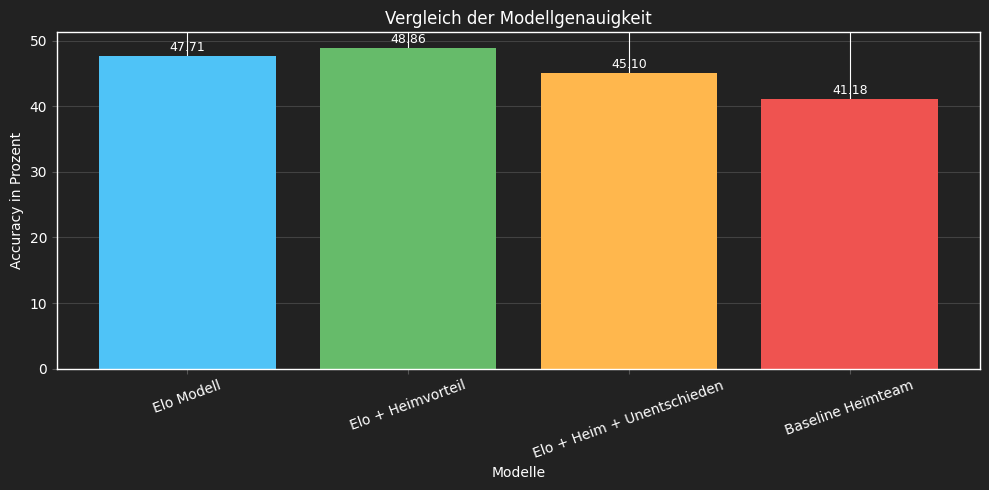

In [84]:
models = [
    "Elo Modell",
    "Elo + Heimvorteil",
    "Elo + Heim + Unentschieden",
    "Baseline Heimteam"
]

accuracies = [
    accuracy_percent,
    accuracy_ha_percent,
    accuracy_draw_model_percent,
    baseline_accuracy_percent
]

colors = ["#4fc3f7", "#66bb6a", "#ffb74d", "#ef5350"]

plt.figure(figsize=(10, 5))

bars = plt.bar(models, accuracies, color=colors)

ax = plt.gca()
ax.set_facecolor("#222222")
plt.gcf().patch.set_facecolor("#222222")

plt.title("Vergleich der Modellgenauigkeit", color="white")
plt.xlabel("Modelle", color="white")
plt.ylabel("Accuracy in Prozent", color="white")

plt.xticks(rotation=20, color="white")
plt.yticks(color="white")

for spine in ax.spines.values():
    spine.set_color("white")

plt.grid(axis="y", color="white", alpha=0.15)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.3,
        f"{yval:.2f}",
        ha="center",
        va="bottom",
        color="white",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In diesem Schritt wurden die verschiedenen Modellvarianten grafisch miteinander verglichen, um die Unterschiede in der Vorhersagegenauigkeit besser sichtbar zu machen. Die Grafik zeigt, dass das einfache Elo Modell eine Accuracy von etwa 47.71 Prozent erreicht und damit bereits besser abschneidet als die Baseline, bei der immer ein Heimsieg vorhergesagt wird und nur auf etwa 41.18 Prozent kommt.

Durch die Erweiterung mit dem Heimvorteil verbessert sich das Modell leicht auf rund 48.86 Prozent. Das deutet darauf hin, dass der Heimvorteil im Fußball eine Rolle spielt und sinnvoll in das Modell integriert werden kann. Die zusätzliche Berücksichtigung von Unentschieden führt dagegen zu einer Verschlechterung der Accuracy auf etwa 45.10 Prozent. Obwohl die Idee dahinter logisch ist, zeigt sich hier, dass einfache Regeln nicht automatisch zu besseren Ergebnissen führen.

Insgesamt macht die Grafik deutlich, dass das Elo Modell mit Heimvorteil aktuell die beste Variante darstellt. Gleichzeitig wird sichtbar, dass weitere Anpassungen sorgfältig geprüft werden müssen, da sie das Modell auch verschlechtern können.

## Analyse der Fehlvorhersagen

In [85]:
#Falsche vorhersagen
wrong_predictions = df[df["Predicted_HA"] != df["FTR"]]

wrong_predictions.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,Season,TotalGoals,HomeEloBefore,AwayEloBefore,Predicted,Baseline,Predicted_HA,Predicted_Draw_Model
0,2023-08-18,Werder Bremen,Bayern Munich,0,4,A,2023/24,4,1500.0,1500.0,D,H,H,H
1,2023-08-19,Augsburg,M'gladbach,4,4,D,2023/24,8,1500.0,1500.0,D,H,H,H
2,2023-08-19,Hoffenheim,Freiburg,1,2,A,2023/24,3,1500.0,1500.0,D,H,H,H
10,2023-08-26,M'gladbach,Leverkusen,0,3,A,2023/24,3,1500.0,1510.0,A,H,H,H
11,2023-08-26,Heidenheim,Hoffenheim,2,3,A,2023/24,5,1490.0,1490.0,D,H,H,H


In [86]:
#Meiste Fehler
pd.crosstab(wrong_predictions["FTR"], wrong_predictions["Predicted_HA"])

Predicted_HA,A,H
FTR,,
A,0,135
D,27,131
H,20,0


In [87]:
error_rate = 100 - accuracy_ha_percent
error_rate

np.float64(51.14)

Ein genauerer Blick auf die falschen Vorhersagen zeigt, in welchen Situationen das Modell Probleme hat. Auffällig ist, dass viele Fehler bei Spielen entstehen, die nicht eindeutig sind. Gerade bei Begegnungen mit ähnlichen Elo Werten entscheidet sich das Modell häufig für einen Sieger, obwohl das tatsächliche Ergebnis anders ausfällt.

Die Kreuztabelle macht deutlich, dass besonders viele Auswärtssiege und Unentschieden falsch eingeschätzt werden. In vielen Fällen wird ein Heimsieg vorhergesagt, obwohl das Spiel entweder unentschieden endet oder das Auswärtsteam gewinnt. Die Fehlerrate liegt insgesamt bei etwa 51 Prozent, was zeigt, dass ein großer Teil der Spiele weiterhin schwer vorherzusagen ist. Das ist im Fußball jedoch nicht ungewöhnlich, da viele Faktoren wie Tagesform oder Zufall eine Rolle spielen. Insgesamt wird deutlich, dass das Modell vor allem bei klaren Favoriten gut funktioniert, aber Schwierigkeiten bei ausgeglichenen oder überraschenden Spielen hat.

## Wann funktioniert das Modell gut und wann nicht

In [90]:
df["EloDiff"] = abs(df["HomeEloBefore"] - df["AwayEloBefore"])

df["MatchType"] = df["EloDiff"].apply(
    lambda x: "ausgeglichen" if x < 50 else "klarer Favorit"
)

performance_by_type = df.groupby("MatchType").apply(
    lambda x: (x["Predicted_HA"] == x["FTR"]).mean() * 100
)

performance_by_type

MatchType
ausgeglichen      42.465753
klarer Favorit    54.687500
dtype: float64

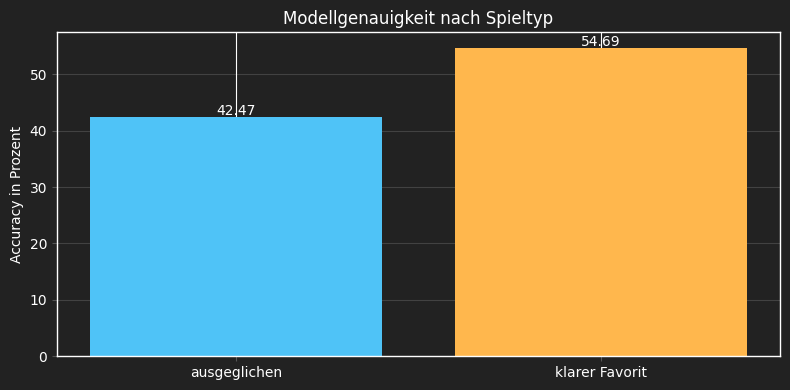

In [89]:
labels = performance_by_type.index
values = performance_by_type.values

colors = ["#4fc3f7", "#ffb74d"]

plt.figure(figsize=(8,4))
bars = plt.bar(labels, values, color=colors)

ax = plt.gca()
ax.set_facecolor("#222222")
plt.gcf().patch.set_facecolor("#222222")

plt.title("Modellgenauigkeit nach Spieltyp", color="white")
plt.ylabel("Accuracy in Prozent", color="white")

plt.xticks(color="white")
plt.yticks(color="white")

for spine in ax.spines.values():
    spine.set_color("white")

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.3,
        f"{yval:.2f}",
        ha="center",
        color="white"
    )

plt.grid(axis="y", color="white", alpha=0.15)
plt.tight_layout()
plt.show()

Ein genauerer Vergleich zeigt, dass die Modellgenauigkeit stark davon abhängt, wie unterschiedlich stark die beiden Teams sind. Bei Spielen mit einem klaren Favoriten funktioniert das Modell deutlich besser. In diesen Fällen ist die Wahrscheinlichkeit hoch, dass das stärkere Team gewinnt, was durch die Elo Werte gut abgebildet wird. Anders sieht es bei ausgeglichenen Spielen aus. Wenn die Elo Werte beider Teams ähnlich sind, sinkt die Genauigkeit spürbar. In solchen Situationen ist das Ergebnis schwerer vorherzusagen, da kleine Faktoren oder Zufall eine größere Rolle spielen.

Diese Beobachtung erklärt auch, warum das Modell insgesamt keine sehr hohe Accuracy erreicht. Ein großer Teil der Spiele gehört zu den ausgeglichenen Begegnungen, bei denen selbst ein gutes Modell an Grenzen stößt. Insgesamt zeigt sich, dass das Elo Modell besonders gut für klare Leistungsunterschiede geeignet ist, während es bei engen Spielen deutlich an Genauigkeit verliert.

## Grenzen des Elo Modells

Neben den positiven Ergebnissen zeigt die Analyse auch einige klare Grenzen des verwendeten Modells. Ein zentraler Punkt ist, dass das Elo Modell nur auf vergangenen Spielergebnissen basiert. Andere wichtige Faktoren wie aktuelle Form, Verletzungen oder taktische Veränderungen werden nicht berücksichtigt. Außerdem wird jedes Spiel unabhängig betrachtet. Es wird nicht einbezogen, ob ein Team in den letzten Spielen besonders gut oder schlecht gespielt hat. Dadurch kann das Modell kurzfristige Entwicklungen nur schwer erfassen.

Ein weiteres Problem ist die Behandlung von Unentschieden. Obwohl diese im Fußball häufig vorkommen, kann das Modell sie nur schwer korrekt vorhersagen. Die einfache Erweiterung hat gezeigt, dass solche Anpassungen nicht automatisch zu besseren Ergebnissen führen.Zusätzlich spielt auch Zufall eine Rolle im Fußball. Einzelne Ereignisse wie Platzverweise oder individuelle Fehler können ein Spiel stark beeinflussen, ohne dass dies im Modell abgebildet wird. Insgesamt wird deutlich, dass das Elo Modell eine gute Grundlage darstellt, aber viele reale Einflüsse nicht berücksichtigt und daher nur begrenzt genaue Vorhersagen liefern kann.

## Mögliche Verbesserungen des Modells

Auf Basis der bisherigen Ergebnisse lassen sich mehrere Ansätze ableiten, wie das Modell weiter verbessert werden könnte. Ein wichtiger Ansatz wäre die Berücksichtigung der aktuellen Form eines Teams. Dafür könnten beispielsweise die Ergebnisse der letzten Spiele stärker gewichtet werden. Auch zusätzliche Daten wie erwartete Tore oder Spielerbewertungen könnten integriert werden, um die tatsächliche Spielstärke genauer abzubilden. Der Heimvorteil könnte ebenfalls differenzierter modelliert werden, da er je nach Team unterschiedlich stark ausfallen kann. Ein weiterer Ansatz wäre die Nutzung komplexerer Modelle, die mehrere Einflussfaktoren gleichzeitig berücksichtigen und nicht nur auf einem einzelnen Rating basieren. Diese Ansätze zeigen, dass das Elo Modell zwar eine gute Grundlage bietet, aber durch zusätzliche Informationen und Methoden weiter verbessert werden kann.

## Fazit

In diesem Projekt wurde ein Elo Modell für die Bundesliga umgesetzt und auf zwei Saisons angewendet. Ziel war es vor allem zu untersuchen, wie gut sich Teamstärken damit abbilden lassen und ob sich damit auch Spielergebnisse sinnvoll vorhersagen lassen.

Grundsätzlich zeigt sich, dass das Modell die Stärke der Teams ganz gut widerspiegelt. Teams, die auch in der Realität stark sind, landen im Modell oben, während schwächere Teams niedrigere Werte haben. Besonders im Verlauf einer Saison wird sichtbar, wie sich Teams entwickeln, was gut zum eigentlichen Gedanken hinter dem Elo System passt.

Bei der Vorhersage von Spielen wird aber auch schnell klar, dass das Modell seine Grenzen hat. Die Trefferquote ist zwar besser als bei einer sehr einfachen Strategie, aber insgesamt nicht besonders hoch. Das liegt wahrscheinlich daran, dass im Fußball viele Faktoren eine Rolle spielen, die hier gar nicht berücksichtigt werden.

Die Erweiterung um den Heimvorteil hat das Modell leicht verbessert, was auch logisch ist. Die Idee, Unentschieden stärker einzubauen, war zwar naheliegend, hat aber nicht zu besseren Ergebnissen geführt. Dadurch sieht man ganz gut, dass nicht jede zusätzliche Regel automatisch hilft.

Interessant war vor allem die Analyse der Fehlvorhersagen. Dabei fällt auf, dass das Modell vor allem bei engen Spielen Probleme hat. Wenn zwei Teams ähnlich stark sind, ist das Ergebnis einfach schwer vorherzusagen. Bei klaren Favoriten funktioniert das Ganze dagegen deutlich besser.

Insgesamt kann man sagen, dass das Elo Modell eine gute Grundlage bietet, um Teamstärken zu vergleichen. Für genaue Vorhersagen reicht es aber alleine nicht aus. Dafür müsste man noch mehr Informationen einbauen, zum Beispiel zur aktuellen Form oder zu einzelnen Spielern.

Alles in allem hat das Projekt gezeigt, wie man so ein Modell nicht nur umsetzt, sondern auch kritisch bewertet und an seine Grenzen stößt.